## A Little About Splice Site Classifiers

Splice sites are fundamental to eukaryotic gene expression. While the human genome contains approximately 20,000-25,000 protein-coding genes, we observe far more protein diversity than this number would suggest. Much of this complexity arises from alternative splicing, where pre-mRNAs have portions called introns excised by the spliceosome, while the remaining exons can be joined in different configurations to produce distinct proteins from the same gene.

### Why Splice Site Prediction Matters

Accurate splicing is essential for proper gene expression. When the spliceosome cannot correctly identify splice sites, it can result in exon skipping or intron retention, often producing non-functional proteins. The clinical importance is substantial - one review article estimates that between 15-30% of disease causing variants may impact splicing (Wang et al., 2023), contributing to disorders ranging from cancer to spinal muscular atrophy. This makes computational splice site prediction a critical tool for interpreting genetic variants and understanding disease mechanisms.

### The Computational Challenge

Most splice sites are marked by canonical GT (donor) and AG (acceptor) dinucleotides, but this creates a massive signal-to-noise problem. If modeled as a uniform distribution, GT and AG dinucleotides would occur every 16 base pairs by chance, and given that there are over 3 billion base pairs in the human genome, we would expect 187 million observances of this motif. Meanwhile, the GENCODE annotations for human show ~350,000-400,000 unique splice sites.

Distinguishing real splice sites from decoys requires sophisticated pattern recognition that considers sequence context, evolutionary conservation, and regulatory elements. Machine learning approaches have proven most successful at this task by learning complex sequence patterns that extend well beyond the canonical dinucleotides. Models from logistic regression to convolutional neural networks have been built to tackle this problem.

### Enter Protisplice

Building accurate splice site predictors requires high-quality, well-annotated training datasets. Protisplice streamlines this first step by:

- Extracting real splice sites from any organism with GFF3 annotations
- Generating appropriate negative controls from intergenic, intronic, and exonic regions
- Providing data augmentation tools to create challenging false positives
- Supporting expression-based filtering to focus on biologically relevant transcripts
- Enabling motif analysis to understand sequence patterns

This tutorial demonstrates the complete workflow from sequence extraction through motif visualization and dataset preparation for machine learning applications.

## Protisplice Tutorial

This tutorial will show you how to extract splice junctions, find motifs, and create a robust set of decoy sequences for downstream ML or DL classifiers.

### Requirements

`logomaker` and `matplotlib` are not required dependencies of this repo, but you can install them using `pip install logomaker matplotlib` or `uv add logomaker matplotlib` if using `uv`. If you built installed the package using `pip install -e .` all other dependencies will be handled.

### Storage and Performance

Below I've included some shell commands to follow this tutorial using the human genome. Note that the reference genome and annotations are large files, and you will need **15GB** of space or more to follow using human data. If you're short on space but still want to follow, you can use any other organism you'd like (I'd recommend Plasmodium as it is a small genome, and a link to that genome is provided for you).

If you have less than 16GB of available RAM or older hardware, I **strongly** suggest splitting the genome by chromosome and running the workflow only on one chromosome at a time. This is explained below, but for reference, my MacBook Pro (M4 Pro, 24GB RAM) took about 4 seconds total for computing the junctions and sampling all decoy sequences for chromosome 1.

In [1]:
from itertools import islice
from Bio.Seq import Seq
import logomaker
import matplotlib.pyplot as plt
import pandas as pd
from protisplice import SpliceSeqExtractor, ExtractionParams, SamplingParams, JunctionType, StrandType, TranscriptFilter
from protisplice import generate_pfm, generate_ppm, generate_pwm
from protisplice import write_sequences
from protisplice import inject_consensus, remove_consensus

## Tutorial Data: Human Chromosome 1

For the data, we will work with human chromosome 1 (GENCODE FASTA + annotations). This class should work with any GFF3 and FASTA from any species, provided that you're using the same version numbers for both files (else the annotations won't match the proper coordinates). Of course, annotation quality is going to vary between species, especially for those that aren't very well-studied.

GENCODE doesn't provide per-chromosome annotations as separate files, so I will include some simple bash scripts that I used to split out the whole genome by chromosome, located in `protisplice/bash_utils`. It will take a few minutes for `split_gff3` to execute - just be aware it is working!

**Please have at least 15GB of free space available for the files below!!**

If storage space is an issue, you can follow along with smaller genomes, like protists, which will still showcase the package's utility -- just be sure to have the same version of GFF3 and FASTA for any species you decide to use.

https://protists.ensembl.org/Plasmodium_falciparum/Info/Index

In [ ]:
# NOTE - These files take up total about 4.6GB of space -- make sure you have room for this!
mkdir -p data/input

wget -P data/input https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_48/gencode.v48.annotation.gff3.gz
wget -P data/input https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_48/GRCh38.primary_assembly.genome.fa.gz
cd data/input
gunzip *.gz

In [ ]:
# This is pretty slow, but you can kill the terminal after chr1 finishes if you don't need the rest.
# This essentially is duplicating another gff3, which will take up ~1.7GB.
# If you don't need the original annotations, feel free to delete it once this finishes.
bash bash_utils/split_gff3.sh

## Initialization and Attributes of SpliceSeqExtractor

First, we can instantiate the class. Note that the GFF3 path and FASTA paths are required arguments, and the transcript filter is optional. By default, the transcript filter is `"all"`, but we can filter by transcripts that are considered protein coding by the annotation file with `"protein_coding"`. There is another option for filtering the transcripts with RNA-seq data, but we will ignore this for now.

In [2]:
extraction_params = ExtractionParams(n_exon=10, n_intron=10) # starting with a window size of 20 for demonstration
sampling_params = SamplingParams(window_size=20) # to get same length decoys as true splice sites, use n_exon + n_intron
extractor = SpliceSeqExtractor(gff_path="data/input/gencode.v48.annotation.chr1.gff3",
                                fasta_path="data/input/chr1.fa",
                                  transcript_filter=TranscriptFilter.ALL,
                                    extraction_params=extraction_params,
                                    sampling_params=SamplingParams(window_size=20))


The extractor has two properties - `junctions` and `transcripts`. These are both lazy-loaded, so they will be computed upon any method that requires these properties. First, we can take a look at the identified junctions:

In [3]:
junctions = extractor.junctions # may take a few seconds to compute depending on the size

Because the extractor parses per-transcript, we end up with many duplicate splice junctions that appear in multiple transcripts (mostly due to alternative splicing). `SpliceSeqExtractor.unique_junctions` will give you only unique junctions by coordinate. Unless you need to weight junctions based on the number of transcripts they appear in, using `unique_junctions` is generally a more appropriate method for motif analysis and ML dataset generation.

In [6]:
uniq = extractor.unique_junctions
print(len(junctions))
print(len(uniq))

335272
72396


The junctions are generated using a `SpliceJunction` object, which essentially is just a dictionary containing the transcript ID, sequence ID (usually going to be the chromosome # for most purposes), the coordinate of the junction, strand, and the type of junction - either donor or acceptor.

Note that the junction coordinates are 1-based and represent the first exon base along the junction (i.e. coord - 1 is the end of the intron). 

Lastly, the transcript ID is suffixed with ID_junctype_num, where junctype is either donor/acceptor, and num is the sequential order in which each splice junction is found, starting at 0.

To get a better look at these SpliceJunction objects, let's look at the first 5:

In [7]:
uniq[:5]

[SpliceJunction(id='ENST00000615329_donor_8', seqid='chr1', coord=213242297, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.DONOR: 'donor'>),
 SpliceJunction(id='ENST00000367667_donor_11', seqid='chr1', coord=176116624, strand=<StrandType.NEGATIVE: '-'>, junction_type=<JunctionType.DONOR: 'donor'>),
 SpliceJunction(id='ENST00000337248_acceptor_3', seqid='chr1', coord=24373810, strand=<StrandType.NEGATIVE: '-'>, junction_type=<JunctionType.ACCEPTOR: 'acceptor'>),
 SpliceJunction(id='ENST00000443751_donor_1', seqid='chr1', coord=77783351, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.DONOR: 'donor'>),
 SpliceJunction(id='ENST00000717022_acceptor_5', seqid='chr1', coord=113899872, strand=<StrandType.POSITIVE: '+'>, junction_type=<JunctionType.ACCEPTOR: 'acceptor'>)]

We can also take a look at all of the transcripts found using `extractor.transcripts`, which will return a `Transcript` object. `Transcript.info` contains the sequence ID from the associated FASTA and the strand type. 

`Transcript.exons` contains the 1-based start and end coordinates for every exon in the transcript and exons are stored a list of tuples `[(start1, end1), (start2, end2) ...]`. `Transcript.introns` is initiated to `None` but can be determined using `Transcript.get_intron_coords`, and it is formatted in the same way as `Transcript.exons`. 

The intron coords can already be inferred from the existing exon coordinates, and it would take up more memory to explicitly hold the intron coordinates as well, but the method exists if you need it.

In [ ]:
transcripts = extractor.transcripts
dict(islice(transcripts.items(), 5))

In [ ]:
len(transcripts)

### Quick Note about Coordinate System

Note that all API-facing coordinates are 1-based and inclusive on both ends. GFF3 files display 1-based coordinates, but FASTA indexing and fetching with `pysam` uses 0-based. The conversion is handled for you internally.


Anyways - let's continue by using one of the main methods of the `SpliceSeqExtractor` to find all of the splice junctions in our organism (or at least whatever has been already annotated). All extraction and sampling methods will return a `JunctionData` object. These essentially contain our `SpliceJunction` from before, but with a bit more information -- we also will have the `window_start`, `window_end` and `sequence`. The start and end are determined from the `n_exon` and `n_intron` that we passed in earlier, and the sequence is simply fetched from the corresponding FASTA.

These `JunctionData` objects are the core of the workflow and can be output to files or augmented, which will be shown later.

In [8]:
true_ss = extractor.sequence_extractor.extract_splice_sites(uniq)

## Motif Discovery and Visualization for Splice Sites

To visualize the different motifs between donors and acceptors, we'll split the sequences based on their junction type into two lists using a simple list comprehension. 

In [9]:
acceptors = [true_ss[i].sequence for i in range(len(true_ss)) if true_ss[i].junction.junction_type == JunctionType.ACCEPTOR]
# acceptors[:5]

donors = [true_ss[i].sequence for i in range(len(true_ss)) if true_ss[i].junction.junction_type == JunctionType.DONOR]
donors[:5]

['AATGATAGAGGTCAGGAACT',
 'CAGTTCTCAGGTAAACGATA',
 'TCTCTCCCAGGTAAATAAAA',
 'CCAAAACATGGTGAGTATAT',
 'AAGTAACTGAGTAAGTGGAC']

In addition to the sequence extraction methods, I have also provided methods to generate position frequency, weight, and probability matrices from a list of sequences. All of these methods will return a pandas DataFrame, where the columns are the nucleotides A, T, G, C, and the values represent either the count, log-odds ratio, or the probability of each nucleotide at each position.  

In this case, I've used the position probability matrices to visualize the acceptor and donor motifs for human chromosome 1.

In [10]:
ppm_donors = generate_ppm(donors)
ppm_acceptors = generate_ppm(acceptors)

ppm_acceptors # 4x20 matrix

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
A,0.103110,0.115511,0.124039,0.130894,0.107234,0.109213,0.244287,0.071648,0.992699,0.003261,0.276084,0.260952,0.266999,0.239243,0.270009,0.255323,0.272489,0.286674,0.267724,0.264826
C,0.270984,0.283803,0.299465,0.305874,0.314263,0.279484,0.280571,0.641289,0.001784,0.002480,0.151878,0.200089,0.226703,0.275192,0.238546,0.234533,0.245207,0.241305,0.224334,0.248077
G,0.107123,0.116960,0.100825,0.098066,0.071257,0.078949,0.197804,0.016414,0.002592,0.992281,0.455161,0.194181,0.231942,0.219624,0.214413,0.267306,0.258945,0.227483,0.260144,0.257301
T,0.518783,0.483725,0.475672,0.465166,0.507246,0.532354,0.277338,0.270650,0.002926,0.001979,0.116877,0.344778,0.274356,0.265940,0.277032,0.242838,0.223359,0.244538,0.247798,0.229796


Now, we can pass in our dataframes into `logomaker` to visualize our motifs! I have simply made a list comprehension of the numbers from -10:10
to pass in as our labels, since by default, the x-ticks will be incremented by 2.5 (which doesn't make a lot of sense for discrete positions). 

The simplest way to change the labels is just to change the indices on the dataframe we pass in. You can customize the plot using `matplotlib` methods however you'd like.

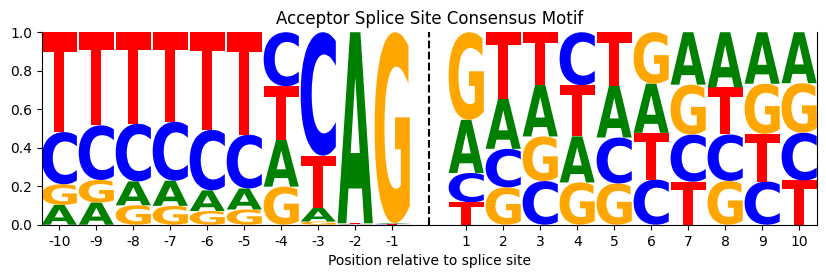

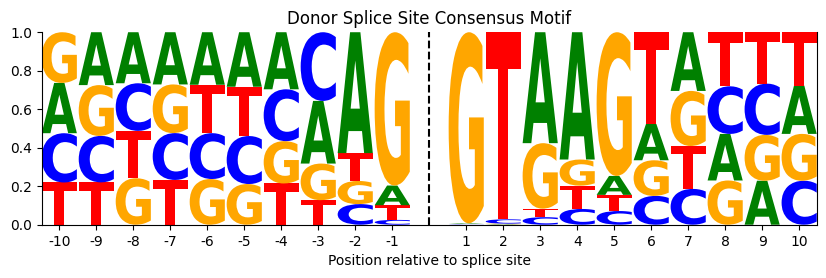

In [11]:
positions = [i for i in range(-10, 0)] + [i for i in range(1, 11)]


ppm_acceptors_T = ppm_acceptors.T # dfs need to be transposed for logomaker compatability
ppm_donors_T = ppm_donors.T

ppm_acceptors_T.index = positions
ppm_donors_T.index = positions

logo_acceptor = logomaker.Logo(ppm_acceptors_T, color_scheme='classic')
logo_acceptor.ax.spines['top'].set_visible(False)
logo_acceptor.ax.set_xticks(positions)
logo_acceptor.ax.set_xticklabels(positions)
plt.xlabel("Position relative to splice site")
plt.axvline(x=0, color="black", linestyle="--")
plt.title("Acceptor Splice Site Consensus Motif")
plt.show()

logo_donor = logomaker.Logo(ppm_donors_T, color_scheme='classic')
logo_donor.ax.spines['top'].set_visible(False)
logo_donor.ax.set_xticks(positions)
logo_donor.ax.set_xticklabels(positions)
plt.xlabel("Position relative to splice site")
plt.axvline(x=0, color="black", linestyle="--")
plt.title("Donor Splice Site Consensus Motif")
plt.show()

## Dataset Generation for Predicting Splice Sites

In addition to just looking at our motifs, we can also use the extractor's random sampling methods to generate higher-quality "decoy" sequences. For model training, we want to maximize the variety of the types of sequences we train on. Using solely intergenic sequences might lack certain structural features of introns/exons, and essentially make it too easy to discern splice sites versus non-splice sites. 

For example, if we were classifying images of cats, we wouldn't want to train the model with pictures of grass for our non-cat pictures.

To create more generalizable models, the extractor has a couple of methods for sampling regions close to splice sites (in introns and exons), but exclude the splice site itself. Users can pass in a buffer size to start sampling within a certain region away from the junction. Users are also able to sample random intergenic regions as well, if desired.

In [12]:
intergenic_seqs = extractor.extract_intergenic_sequences(target_count=5)
exonic_seqs = extractor.extract_exonic_sequences(target_count=5)
intronic_seqs = extractor.extract_intronic_regions(target_count=5)

### Augmenting Data

Now that we have real sequences from exon and intron regions, we can augment these sequences to create strong false positives. We can choose to either remove a real consensus from a true splice site, or we can add a consensus to a known decoy at the expected position. Since we have extracted the decoy sequences with a buffer zone from known splice sites, we can be more confident that we aren't accidentally generating true positives. We can check the sequences we get against our extracted true positives later as a sanity check as well. While synthetic data like this may not be ideal for model training, it could be informative for testing.

In [13]:
# using a simple example

example_seq = true_ss[0]
example_seq.sequence[8:13] # Note that the "GT" is the consensus motif in this case

'AGGTC'

Consensus location is determined from n_exon of the extraction parameters we passed in earlier.

In [14]:
print(example_seq.sequence[8:13])
example_seq_removed = remove_consensus(example_seq, extraction_params=extraction_params) 
# both inject_consensus and remove_consensus create new objects
# still can access the original data passed in to the function (not modified in-place)
print(example_seq_removed.sequence[8:13])
print(example_seq.sequence[8:13]) 



AGGTC
AGTTC
AGGTC


In [15]:
example_neg = intronic_seqs[0]
print(example_neg.sequence[8:13])
false_pos = inject_consensus(example_neg, extraction_params=extraction_params, junc_type=JunctionType.ACCEPTOR)

print(false_pos.sequence[8:13])
print(example_neg.sequence[8:13])


CCCAG
AGCAG
CCCAG


### Writing Sequences to FASTA

Lastly, you can write out the extracted sequences to FASTA simply using the `write_sequences()` function, which takes in a list of `JunctionData` objects. These objects are the output of all of the extraction methods. All of the important metadata about the `JunctionData` objects are retained in the FASTA header in the format `>seqid_seqtype_strand_winstart_winend`:

In [16]:
count = write_sequences(exonic_seqs, "exonic_decoy_seqs.fasta")

exonic_seqs[0].to_fasta_header()

'>ENST00000696617_exon_+_244051358_244051377'

## Ending Notes and Other Use Cases

With the sequences written out into separate files, users are able to create their own ML pipelines for splice site classification! Hopefully anyone interested in training ML models finds this repo useful. This repository can also serve as a way to show how important our selection of training set is to our model. For those interested in ML applications in bioinformatics, you can play around with creating different datasets to understand how diverse training data can improve a model's generalizability, and you can also compare motifs across species as well.

If you have any questions or issues, please open an issue and I'll get back to you ASAP. 

### References

Robert Wang, Ingo Helbig, Andrew C Edmondson, Lan Lin, Yi Xing, Splicing defects in rare diseases: transcriptomics and machine learning strategies towards genetic diagnosis, Briefings in Bioinformatics, Volume 24, Issue 5, September 2023, bbad284, https://doi.org/10.1093/bib/bbad284